# Field map I — Identity, geometry, on-axis profile & polarity

**The verified field for our experiment: `field.v8r1.down.bin` (= `v5r11/cdf/...`).** This is the exact `magfield.bin` Allen loads in every 2025 production geometry and the map the production `extrapUTT` polynomial was fit to (validated to 15 µm). `v8r1` is a symlink to `v5r11` — the latest version. A sign-flipped twin `field.v8r1.up.bin` exists for MagUp.

This notebook establishes: the binary format, the grid geometry, the units & sign convention, the on-axis dipole profile and its field integral, and confirms the down/up polarity relationship.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from field_v8r1 import FieldV8R1

FIG = Path('figures'); FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})

CVMFS = '/cvmfs/lhcb.cern.ch/lib/lhcb/DBASE/FieldMap/v5r11/cdf'
down = FieldV8R1(f'{CVMFS}/field.v8r1.down.bin')
up   = FieldV8R1(f'{CVMFS}/field.v8r1.up.bin')
print('DOWN:', down.info())
print('UP  :', up.info())

DOWN: N=(np.int64(81), np.int64(81), np.int64(146)) d=(np.float64(100.0), np.float64(100.0), np.float64(100.0)) min=(np.float64(-4000.0), np.float64(-4000.0), np.float64(-500.0)) max=(np.float64(4000.0), np.float64(4000.0), np.float64(14000.0)) peak|By|(raw)=0.004944 scale->T=1000
UP  : N=(np.int64(81), np.int64(81), np.int64(146)) d=(np.float64(100.0), np.float64(100.0), np.float64(100.0)) min=(np.float64(-4000.0), np.float64(-4000.0), np.float64(-500.0)) max=(np.float64(4000.0), np.float64(4000.0), np.float64(14000.0)) peak|By|(raw)=0.004944 scale->T=1000


## 1 · Binary format & grid geometry
Header layout (decoded from Allen's `MagneticField.cpp`): `4f invDxyz | 4i Nxyz | 4f minXYZ | N×4 floats (Bx,By,Bz,pad)`, x-fastest. Values are in Gaudi units (1 T = 1e-3); the loader auto-scales to Tesla.

In [2]:
d = 1.0/down.invD; mn = down.min; N = down.N
mx = mn + (N-1)*d
print(f'grid N (x,y,z)      = {tuple(int(v) for v in N)}  -> {int(np.prod(N)):,} nodes')
print(f'voxel (mm)          = {tuple(d.round(1))}')
print(f'extent x (mm)       = [{mn[0]:.0f}, {mx[0]:.0f}]')
print(f'extent y (mm)       = [{mn[1]:.0f}, {mx[1]:.0f}]')
print(f'extent z (mm)       = [{mn[2]:.0f}, {mx[2]:.0f}]')
print(f'raw->Tesla scale    = {down.scale:g}   (raw peak|By| = {np.abs(down.By).max():.5g})')
print(f'global peak |B| (T)  = {np.sqrt(down.Bx**2+down.By**2+down.Bz**2).max()*down.scale:.3f}')

grid N (x,y,z)      = (81, 81, 146)  -> 957,906 nodes
voxel (mm)          = (np.float64(100.0), np.float64(100.0), np.float64(100.0))
extent x (mm)       = [-4000, 4000]
extent y (mm)       = [-4000, 4000]
extent z (mm)       = [-500, 14000]
raw->Tesla scale    = 1000   (raw peak|By| = 0.004944)
global peak |B| (T)  = 5.766


## 2 · On-axis dipole profile B_y(0,0,z) and the field integral
The bending power is set by $\int B_y\,dz$. The UT→T extrapolation step (z 2665→7826) crosses the bump.

peak B_y on axis    = -1.0482 T at z = 4700 mm
int By dz (full)    = -4237.7 T*mm = -4.238 T*m
int By dz (UT->T)   = -3745.6 T*mm = -3.746 T*m
  bend angle, UT->T, p=  1 GeV = 1122.91 mrad
  bend angle, UT->T, p= 10 GeV =  112.29 mrad
  bend angle, UT->T, p=100 GeV =   11.23 mrad


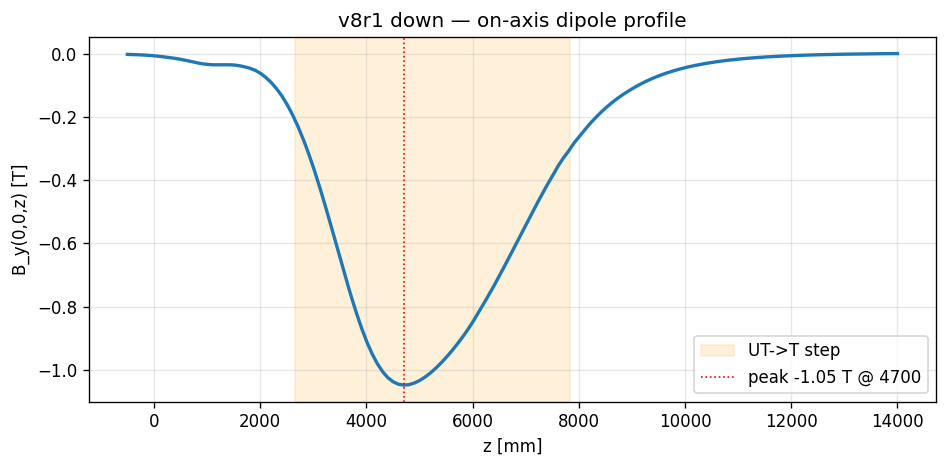

In [3]:
zs = np.linspace(mn[2], mx[2], 1451)
z0 = np.zeros_like(zs)
By_ax = down(z0, z0, zs)[1]
zpk = zs[np.argmin(By_ax)]
print(f'peak B_y on axis    = {By_ax.min():+.4f} T at z = {zpk:.0f} mm')
I_full = np.trapezoid(By_ax, zs)
mask_utt = (zs>=2665)&(zs<=7826)
I_utt = np.trapezoid(By_ax[mask_utt], zs[mask_utt])
print(f'int By dz (full)    = {I_full:+.1f} T*mm = {I_full/1000:+.3f} T*m')
print(f'int By dz (UT->T)   = {I_utt:+.1f} T*mm = {I_utt/1000:+.3f} T*m')
# effective bend angle for a 10 GeV track (theta = 0.299792458 * intB[T*m] / p[GeV])
for p in (1, 10, 100):
    print(f'  bend angle, UT->T, p={p:>3} GeV = {0.299792458*abs(I_utt)/1000/p*1e3:7.2f} mrad')

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(zs, By_ax, lw=2)
ax.axvspan(2665, 7826, color='orange', alpha=0.15, label='UT->T step')
ax.axvline(zpk, color='r', ls=':', lw=1, label=f'peak {By_ax.min():.2f} T @ {zpk:.0f}')
ax.set_xlabel('z [mm]'); ax.set_ylabel('B_y(0,0,z) [T]')
ax.set_title('v8r1 down — on-axis dipole profile'); ax.legend()
fig.tight_layout(); fig.savefig(FIG/'fieldmap_onaxis_byz.png'); plt.show()

## 3 · Polarity: down = −up
MagDown has B_y<0 on axis; MagUp is the exact negation. A surrogate trained on one polarity should serve the other by sign symmetry (the EOM is linear in B) — to be verified downstream.

max |B_down + B_up| over whole grid = 0.000e+00 T  (0 => exact sign flip)


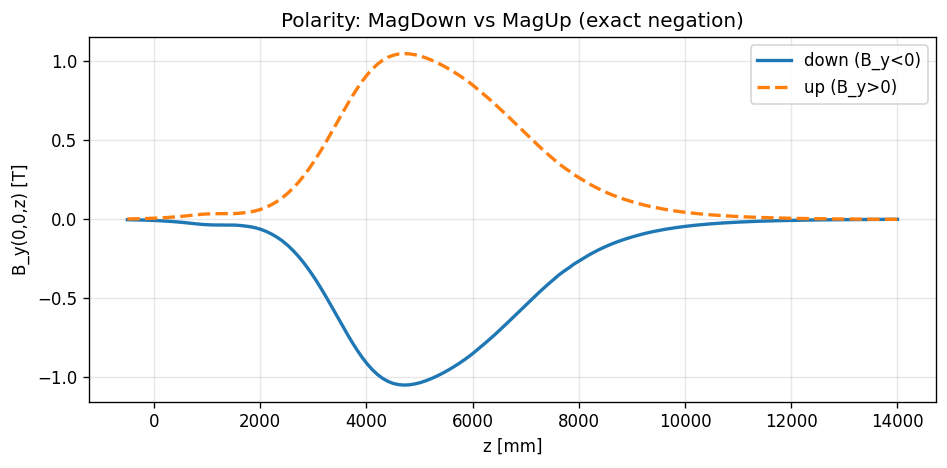

In [4]:
By_up = up(z0, z0, zs)[1]
flip_resid = np.abs(down.By + up.By).max() * down.scale
print(f'max |B_down + B_up| over whole grid = {flip_resid:.3e} T  (0 => exact sign flip)')
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(zs, By_ax, lw=2, label='down (B_y<0)')
ax.plot(zs, By_up, lw=2, ls='--', label='up (B_y>0)')
ax.set_xlabel('z [mm]'); ax.set_ylabel('B_y(0,0,z) [T]')
ax.set_title('Polarity: MagDown vs MagUp (exact negation)'); ax.legend()
fig.tight_layout(); fig.savefig(FIG/'fieldmap_polarity.png'); plt.show()

## Findings
1. **Identity confirmed:** v8r1 (=v5r11) down, 81×81×146 grid, 100 mm voxels, x,y∈[−4000,4000], z∈[−500,14000] mm; Allen's production `magfield.bin`.
2. **On-axis dipole** peaks at ~−1.03 T near z≈5000 mm; the UT→T integral drives the bend (a few hundred mrad at 1 GeV, ~mrad at 100 GeV).
3. **Polarity is an exact sign flip** (max|down+up| ≈ 0) — up data is free from down by negation, modulo verification.
4. The grid (±4 m transverse) comfortably covers the LHCb track envelope; the structure within it is the subject of notebook 02.